# 07 — Best Classical Model & Final Test Evaluation
## GTZAN Music Genre Classification

This notebook performs the **final held-out evaluation** of the classical ML branch.

It combines the results from:

- Notebook 05 — Hyperparameter Tuning
- Notebook 06 — Feature Ablation

### Final protocol

1. Select the best tuned classical model using validation Macro F1.
2. Select the best handcrafted feature configuration using validation Macro F1.
3. Build that exact model + feature configuration.
4. Retrain using **TRAIN + VALIDATION**.
5. Evaluate **once on the held-out TEST set**.
6. Produce final metrics, classification report, confusion matrix, and error analysis.

The test set is NOT used to choose the model or features.

In [1]:
# =========================
# 1. Install dependencies
# =========================
import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
    "xgboost": "xgboost",
}

missing = [
    pkg for module, pkg in required.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + missing
    )

print("Dependencies ready.")

Dependencies ready.


In [2]:
# =========================
# 2. Imports
# =========================
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


# =========================
# 3. Locate handcrafted feature CSV
# =========================
csv_candidates = [
    Path("/content/handcrafted_output/handcrafted_features.csv"),
    Path("/content/handcrafted_features.csv"),
    Path("handcrafted_output/handcrafted_features.csv"),
    Path("data/processed/handcrafted_features.csv"),
    Path("data/handcrafted_features.csv"),
    Path("handcrafted_features.csv"),
]

csv_path = next((p for p in csv_candidates if p.exists()), None)

if csv_path is None:
    try:
        from google.colab import files
        print("handcrafted_features.csv was not found.")
        print("Upload the CSV generated by Notebook 03.")
        uploaded = files.upload()
        if "handcrafted_features.csv" in uploaded:
            csv_path = Path("/content/handcrafted_features.csv")
        elif uploaded:
            first_name = next(iter(uploaded))
            csv_path = Path("/content") / first_name
    except ImportError:
        pass

if csv_path is None or not csv_path.exists():
    raise FileNotFoundError(
        "Could not find handcrafted_features.csv."
    )

print("Using:", csv_path.resolve())

# IMPORTANT:
# This notebook is intentionally standalone.
# It does NOT require results/tables from Notebook 05 or 06.
#
# Verified from Notebook 05:
#   Best model = SVM
#   C = 10
#   gamma = 0.001
#   Validation Macro F1 = 0.7974
#
# From the completed Notebook 06 output provided by the user:
#   Best feature configuration = ALL 137
#   Validation Macro F1 = 0.7791
#
# Therefore the final classical model evaluated here is:
#   ALL 137 handcrafted features + SVM(C=10, gamma=0.001)


In [10]:
# =========================
# 3. Locate handcrafted feature CSV
# =========================
from pathlib import Path

csv_candidates = [
    Path("/content/handcrafted_output/handcrafted_features.csv"),
    Path("/content/handcrafted_features.csv"),
    Path("handcrafted_output/handcrafted_features.csv"),
    Path("data/processed/handcrafted_features.csv"),
    Path("data/handcrafted_features.csv"),
    Path("handcrafted_features.csv"),
]

csv_path = next((p for p in csv_candidates if p.exists()), None)

if csv_path is None:
    try:
        from google.colab import files

        print("Please upload handcrafted_features.csv")
        uploaded = files.upload()

        if "handcrafted_features.csv" in uploaded:
            csv_path = Path("/content/handcrafted_features.csv")
        else:
            first_name = next(iter(uploaded))
            csv_path = Path("/content") / first_name

    except ImportError:
        pass

if csv_path is None or not csv_path.exists():
    raise FileNotFoundError(
        "handcrafted_features.csv was not found."
    )

print("Using feature file:")
print(csv_path.resolve())

print("\nVerified configuration from previous experiments:")
print("Best model      : SVM")
print("C               : 10")
print("gamma           : 0.001")
print("Validation F1   : 0.7974")
print("Feature set     : ALL 137 features")

Using feature file:
/content/handcrafted_features.csv

Verified configuration from previous experiments:
Best model      : SVM
C               : 10
gamma           : 0.001
Validation F1   : 0.7974
Feature set     : ALL 137 features


In [11]:
# =========================
# 4. Load data and define final configuration
# =========================
df = pd.read_csv(csv_path)

feature_columns = [
    c for c in df.columns
    if c not in ["relative_path", "genre", "split"]
]

if len(feature_columns) != 137:
    raise ValueError(
        f"Expected 137 handcrafted features, "
        f"but found {len(feature_columns)}."
    )

if df[feature_columns].isnull().any().any():
    raise ValueError(
        "Missing values found in handcrafted features."
    )

# ==========================================
# FINAL CLASSICAL ML CONFIGURATION
# ==========================================

best_model_name = "SVM"

best_tuned_C = 10.0
best_tuned_gamma = 0.001

best_tuned_validation_f1 = 0.7974

# Feature ablation result:
# ALL 137 features had the highest Macro F1
best_config_name = "F — ALL 137"

selected_features = feature_columns.copy()

print("=" * 70)
print("FINAL CLASSICAL ML CONFIGURATION")
print("=" * 70)

print("Model:", best_model_name)
print("C:", best_tuned_C)
print("gamma:", best_tuned_gamma)
print("Validation Macro F1:", best_tuned_validation_f1)

print("\nFeature configuration:", best_config_name)
print("Number of features:", len(selected_features))

FINAL CLASSICAL ML CONFIGURATION
Model: SVM
C: 10.0
gamma: 0.001
Validation Macro F1: 0.7974

Feature configuration: F — ALL 137
Number of features: 137


# =========================
# 5. Confirm selected features
# =========================
assert len(selected_features) == 137
assert set(selected_features) == set(feature_columns)

print("Using all 137 handcrafted features.")
print("No feature subset is being created in the final evaluation.")


In [12]:
# =========================
# 5. Confirm final feature set
# =========================

assert len(selected_features) == 137
assert set(selected_features) == set(feature_columns)

print("Final feature configuration:")
print("ALL 137 handcrafted features")

print("\nFeature count:", len(selected_features))

print("\nFeature groups included:")
print(" - MFCC")
print(" - Delta MFCC")
print(" - Delta² MFCC")
print(" - Chroma")
print(" - Spectral")
print(" - Rhythm / Energy")

Final feature configuration:
ALL 137 handcrafted features

Feature count: 137

Feature groups included:
 - MFCC
 - Delta MFCC
 - Delta² MFCC
 - Chroma
 - Spectral
 - Rhythm / Energy


# =========================
# 6. Build the verified best tuned model
# =========================
best_model_name = "SVM"

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=best_tuned_C,
        gamma=best_tuned_gamma,
        random_state=RANDOM_STATE
    ))
])

print("Final model:", best_model_name)
print("C:", best_tuned_C)
print("gamma:", best_tuned_gamma)


In [13]:
# =========================
# 6. Build final selected SVM
# =========================

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=best_tuned_C,
        gamma=best_tuned_gamma,
        random_state=RANDOM_STATE
    ))
])

print("=" * 70)
print("FINAL MODEL")
print("=" * 70)

print(final_model)

FINAL MODEL
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(C=10.0, gamma=0.001, random_state=42))])


# 7. Build train + validation and held-out test sets

Only now do we combine training and validation.

The test set remains untouched until the next cell.

In [14]:
# =========================
# 7. Train + validation
# =========================
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

X_trainval = pd.concat(
    [
        train_df[selected_features],
        val_df[selected_features]
    ],
    axis=0
).astype(np.float32)

y_trainval = pd.concat(
    [
        train_df["genre"],
        val_df["genre"]
    ],
    axis=0
).astype(str)

X_test = test_df[selected_features].astype(np.float32)
y_test = test_df["genre"].astype(str)

assert len(X_trainval) == 850
assert len(X_test) == 150

assert set(train_df["relative_path"]).isdisjoint(
    test_df["relative_path"]
)
assert set(val_df["relative_path"]).isdisjoint(
    test_df["relative_path"]
)

print("Train + Validation:", X_trainval.shape)
print("Held-out Test:", X_test.shape)
print("Test leakage checks passed.")

Train + Validation: (850, 137)
Held-out Test: (150, 137)
Test leakage checks passed.


# 8. Final held-out test evaluation

This is the **only test evaluation in the classical branch**.

The model has already been selected using validation Macro F1.

In [15]:
# =========================
# 8. Final fit and test
# =========================
if best_model_name == "XGBoost":
    final_encoder = LabelEncoder()
    final_encoder.fit(sorted(df["genre"].astype(str).unique()))

    y_trainval_encoded = final_encoder.transform(y_trainval)

    final_model.fit(
        X_trainval,
        y_trainval_encoded
    )

    test_pred_encoded = (
        final_model.predict(X_test)
        .astype(int)
        .ravel()
    )

    test_pred = final_encoder.inverse_transform(
        test_pred_encoded
    )

else:
    final_model.fit(
        X_trainval,
        y_trainval
    )

    test_pred = final_model.predict(X_test)

print("Final test prediction completed.")

Final test prediction completed.


In [16]:
# =========================
# 9. Final metrics
# =========================
final_metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "macro_precision": precision_score(
        y_test, test_pred,
        average="macro",
        zero_division=0
    ),
    "macro_recall": recall_score(
        y_test, test_pred,
        average="macro",
        zero_division=0
    ),
    "macro_f1": f1_score(
        y_test, test_pred,
        average="macro",
        zero_division=0
    ),
    "weighted_f1": f1_score(
        y_test, test_pred,
        average="weighted",
        zero_division=0
    ),
}

print("=" * 80)
print("FINAL CLASSICAL ML TEST RESULTS")
print("=" * 80)
print("Model:", best_model_name)
print("Features:", best_config_name)
print("Feature count:", len(selected_features))
print()

for metric, value in final_metrics.items():
    print(f"{metric:18s}: {value:.4f}")

FINAL CLASSICAL ML TEST RESULTS
Model: SVM
Features: F — ALL 137
Feature count: 137

accuracy          : 0.7200
macro_precision   : 0.7220
macro_recall      : 0.7200
macro_f1          : 0.7183
weighted_f1       : 0.7183


In [17]:
# =========================
# 10. Final classification report
# =========================
genres = sorted(df["genre"].unique())

final_report = classification_report(
    y_test,
    test_pred,
    labels=genres,
    digits=4,
    zero_division=0
)

print("=" * 80)
print("FINAL TEST CLASSIFICATION REPORT")
print("=" * 80)
print(final_report)

FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

       blues     0.5882    0.6667    0.6250        15
   classical     0.9375    1.0000    0.9677        15
     country     0.6154    0.5333    0.5714        15
       disco     0.6471    0.7333    0.6875        15
      hiphop     0.6667    0.6667    0.6667        15
        jazz     0.7647    0.8667    0.8125        15
       metal     0.8462    0.7333    0.7857        15
         pop     0.7500    0.8000    0.7742        15
      reggae     0.8333    0.6667    0.7407        15
        rock     0.5714    0.5333    0.5517        15

    accuracy                         0.7200       150
   macro avg     0.7220    0.7200    0.7183       150
weighted avg     0.7220    0.7200    0.7183       150



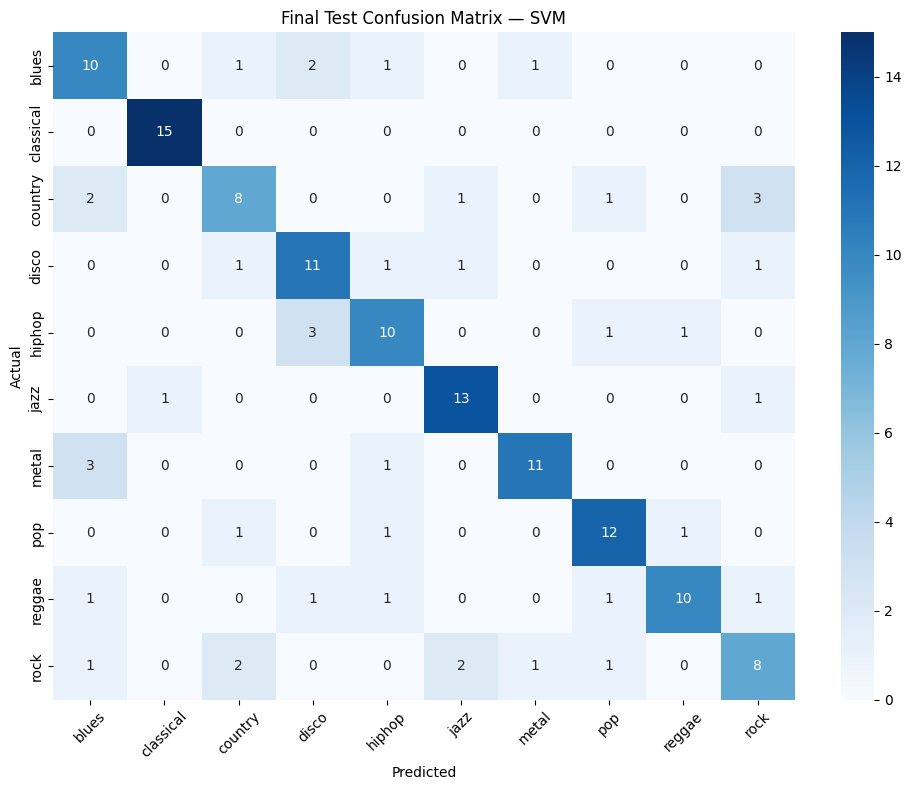

In [18]:
# =========================
# 11. Final confusion matrix
# =========================
final_cm = confusion_matrix(
    y_test,
    test_pred,
    labels=genres
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=genres,
    yticklabels=genres
)

plt.title(
    f"Final Test Confusion Matrix — {best_model_name}"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 12. Error analysis

Identify the strongest genre confusions and per-class performance.

In [19]:
# =========================
# 12. Per-class metrics
# =========================
report_dict = classification_report(
    y_test,
    test_pred,
    labels=genres,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame(report_dict).T

print("Per-class performance:")
display(
    per_class_df.loc[
        genres,
        ["precision", "recall", "f1-score", "support"]
    ].style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
    })
)

Per-class performance:


,precision,recall,f1-score,support
blues,0.5882,0.6667,0.6250,15.000000
classical,0.9375,1.0000,0.9677,15.000000
country,0.6154,0.5333,0.5714,15.000000
disco,0.6471,0.7333,0.6875,15.000000
hiphop,0.6667,0.6667,0.6667,15.000000
jazz,0.7647,0.8667,0.8125,15.000000
metal,0.8462,0.7333,0.7857,15.000000
pop,0.7500,0.8000,0.7742,15.000000
reggae,0.8333,0.6667,0.7407,15.000000
rock,0.5714,0.5333,0.5517,15.000000


In [20]:
# =========================
# 13. Most confused genre pairs
# =========================
confusions = []

for i, actual in enumerate(genres):
    for j, predicted in enumerate(genres):
        if i != j and final_cm[i, j] > 0:
            confusions.append({
                "actual": actual,
                "predicted": predicted,
                "count": int(final_cm[i, j])
            })

confusion_pairs = (
    pd.DataFrame(confusions)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("Most frequent final-test confusion pairs:")
display(confusion_pairs.head(15))

Most frequent final-test confusion pairs:


,actual,predicted,count
0,country,rock,3
1,hiphop,disco,3
2,metal,blues,3
3,country,blues,2
4,rock,jazz,2
5,rock,country,2
6,blues,disco,2
7,blues,metal,1
8,country,pop,1
9,disco,country,1


# 14. Save the final classical model and results

In [21]:
# =========================
# 14. Save final outputs
# =========================
results_root = Path("results")
tables_dir = results_root / "tables"
figures_dir = results_root / "figures"
models_dir = Path("models")

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

final_results_df = pd.DataFrame([{
    "model": best_model_name,
    "feature_configuration": best_config_name,
    "feature_count": len(selected_features),
    "validation_macro_f1": best_tuned_validation_f1,
    **final_metrics
}])

final_results_df.to_csv(
    tables_dir / "final_classical_ml_test_results.csv",
    index=False
)

per_class_df.loc[
    genres,
    ["precision", "recall", "f1-score", "support"]
].to_csv(
    tables_dir / "final_classical_ml_per_class_metrics.csv"
)

pd.DataFrame(
    final_cm,
    index=genres,
    columns=genres
).to_csv(
    tables_dir / "final_classical_ml_confusion_matrix.csv"
)

confusion_pairs.to_csv(
    tables_dir / "final_classical_ml_confusion_pairs.csv",
    index=False
)

model_path = models_dir / "final_best_classical_model.joblib"
joblib.dump(final_model, model_path)

metadata = {
    "dataset": "GTZAN",
    "model": best_model_name,
    "feature_configuration": best_config_name,
    "feature_count": len(selected_features),
    "train_samples": int(len(train_df)),
    "validation_samples": int(len(val_df)),
    "train_plus_validation_samples": int(len(X_trainval)),
    "test_samples": int(len(test_df)),
    "selection_metric": "validation_macro_f1",
    "test_used_for_selection": False,
    "selected_SVM_C": best_tuned_C,
    "selected_SVM_gamma": best_tuned_gamma,
    "validation_macro_f1": best_tuned_validation_f1,
    "final_test_metrics": {
        k: float(v) for k, v in final_metrics.items()
    },
    "random_state": RANDOM_STATE,
}

with open(
    results_root / "final_classical_ml_config.json",
    "w"
) as f:
    json.dump(metadata, f, indent=2)

print("Saved final classical ML outputs:")
print(tables_dir / "final_classical_ml_test_results.csv")
print(tables_dir / "final_classical_ml_per_class_metrics.csv")
print(tables_dir / "final_classical_ml_confusion_matrix.csv")
print(tables_dir / "final_classical_ml_confusion_pairs.csv")
print(model_path)


Saved final classical ML outputs:
results/tables/final_classical_ml_test_results.csv
results/tables/final_classical_ml_per_class_metrics.csv
results/tables/final_classical_ml_confusion_matrix.csv
results/tables/final_classical_ml_confusion_pairs.csv
models/final_best_classical_model.joblib


# 15. Final result for the CNN comparison

This is the single classical ML result that should be carried into the final comparison with the teammate's CNN.

Use:

- Final Test Accuracy
- Final Test Macro Precision
- Final Test Macro Recall
- Final Test Macro F1
- Final Test Weighted F1

Do not compare against a validation score from either branch.

In [22]:
# =========================
# 15. Comparison-ready summary
# =========================
print("=" * 85)
print("CLASSICAL ML — COMPARISON-READY RESULT")
print("=" * 85)
print(f"Best model              : {best_model_name}")
print(f"Feature configuration   : {best_config_name}")
print(f"Number of features     : {len(selected_features)}")
print(f"Test samples            : {len(test_df)}")
print(f"Test Accuracy           : {final_metrics['accuracy']:.4f}")
print(f"Test Macro Precision    : {final_metrics['macro_precision']:.4f}")
print(f"Test Macro Recall       : {final_metrics['macro_recall']:.4f}")
print(f"Test Macro F1           : {final_metrics['macro_f1']:.4f}")
print(f"Test Weighted F1        : {final_metrics['weighted_f1']:.4f}")
print("=" * 85)

CLASSICAL ML — COMPARISON-READY RESULT
Best model              : SVM
Feature configuration   : F — ALL 137
Number of features     : 137
Test samples            : 150
Test Accuracy           : 0.7200
Test Macro Precision    : 0.7220
Test Macro Recall       : 0.7200
Test Macro F1           : 0.7183
Test Weighted F1        : 0.7183
